# PCA for Face Recognition: Eigenfaces

This notebook demonstrates **Principal Component Analysis (PCA)** applied to a dataset of facial images, implementing the classic **Eigenfaces** method (Turk & Pentland, 1991).

## Conceptual Difference from SVD Compression

| Aspect | SVD Image Compression | PCA Eigenfaces |
|--------|----------------------|----------------|
| **Input** | Single image as 2D matrix | Dataset of images as flattened vectors |
| **Goal** | Compress one image | Find shared patterns across images |
| **Components** | Rank-1 matrices | Eigenfaces (basis images) |
| **Reconstruction** | Approximate original image | Project onto eigenface subspace |

## Mathematical Foundation

Given a dataset of $n$ images, each flattened to a vector $x_i \in \mathbb{R}^d$:

1. **Center the data**: $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$, then $\tilde{x}_i = x_i - \bar{x}$

2. **Compute covariance matrix**: $C = \frac{1}{n-1}X^T X$ where $X$ has centered images as rows

3. **Eigendecomposition**: $C = V \Lambda V^T$ where columns of $V$ are **principal components** (eigenfaces)

4. **Project**: $z_i = V_k^T \tilde{x}_i$ (low-dimensional representation)

5. **Reconstruct**: $\hat{x}_i = V_k z_i + \bar{x}$

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))

from src.svd import PCA
from src.metrics import psnr, relative_error

print("All modules loaded successfully!")

All modules loaded successfully!


## 1. Load the Olivetti Faces Dataset

The Olivetti Faces dataset contains 400 grayscale images of 40 subjects (10 images per subject).

In [16]:
import io
from contextlib import redirect_stdout

with io.StringIO() as buf, redirect_stdout(buf):
    faces = fetch_olivetti_faces(shuffle=True, random_state=42)

X = faces.data  # Shape: (400, 4096) - flattened 64x64 images
y = faces.target  # Subject labels (0-39)
image_shape = (64, 64)

print(f"Dataset shape: {X.shape}")
print(f"Number of images: {X.shape[0]}")
print(f"Pixels per image: {X.shape[1]} ({image_shape[0]}×{image_shape[1]})")
print(f"Number of subjects: {len(np.unique(y))}")
print(f"Pixel value range: [{X.min():.3f}, {X.max():.3f}]")

Dataset shape: (400, 4096)
Number of images: 400
Pixels per image: 4096 (64×64)
Number of subjects: 40
Pixel value range: [0.000, 1.000]


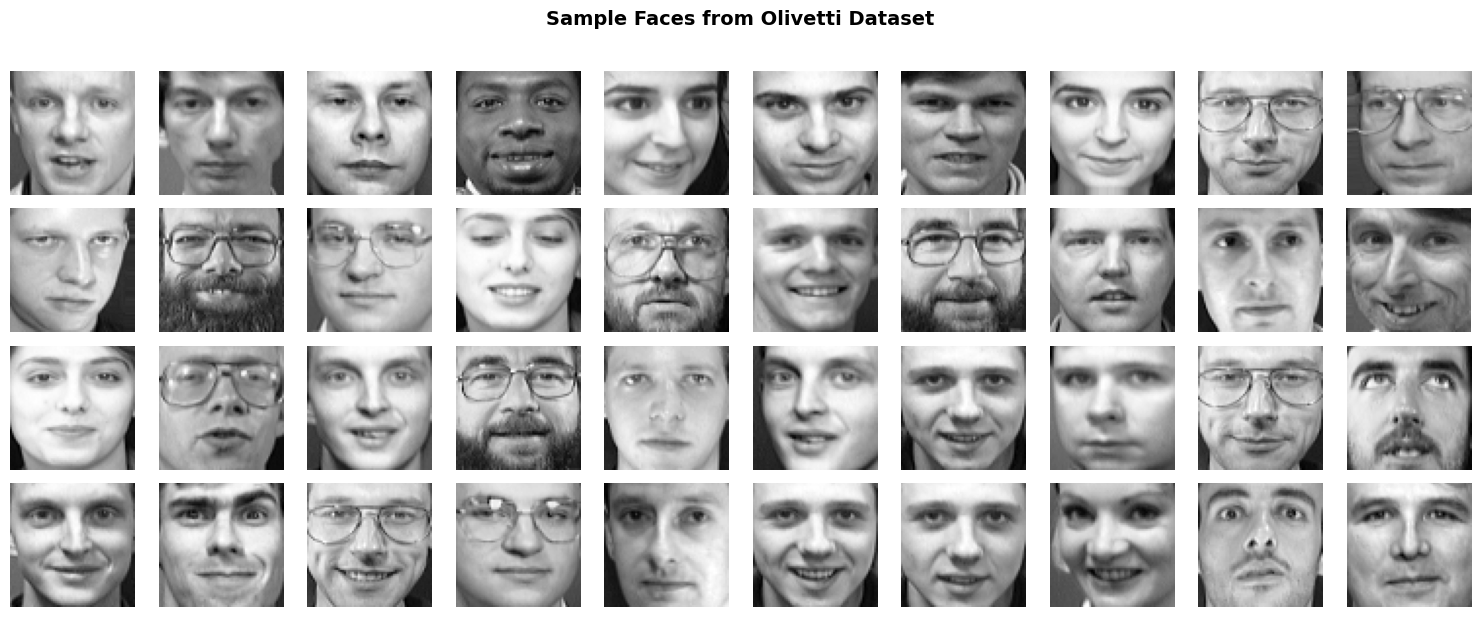

In [17]:
fig, axes = plt.subplots(4, 10, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(image_shape), cmap='gray')
    ax.axis('off')

fig.suptitle('Sample Faces from Olivetti Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Fit PCA and Visualize Eigenfaces

We'll use our custom PCA implementation to extract the principal components (eigenfaces).

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")

Training set: 320 images
Test set: 80 images


In [19]:
# Fit PCA on training data (keeping all components initially)
pca_full = PCA(n_components=min(X_train.shape))
pca_full.fit(X_train)

print(f"Number of components: {pca_full.n_components_}")
print(f"Total variance explained: {pca_full.explained_variance_ratio_.sum()*100:.2f}%")

Number of components: 320
Total variance explained: 100.00%


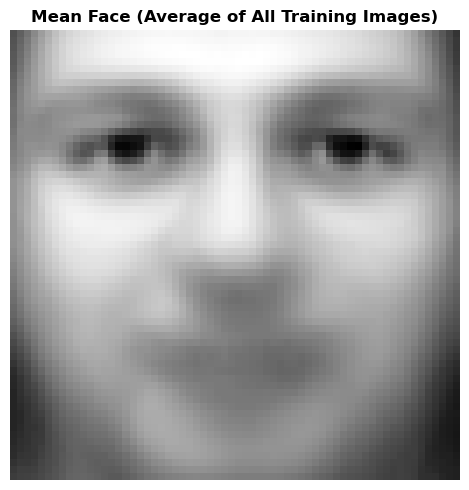

In [20]:
# Visualize the mean face
fig, ax = plt.subplots(figsize=(5, 5))
mean_face = pca_full.mean_.reshape(image_shape)
ax.imshow(mean_face, cmap='gray')
ax.set_title('Mean Face (Average of All Training Images)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

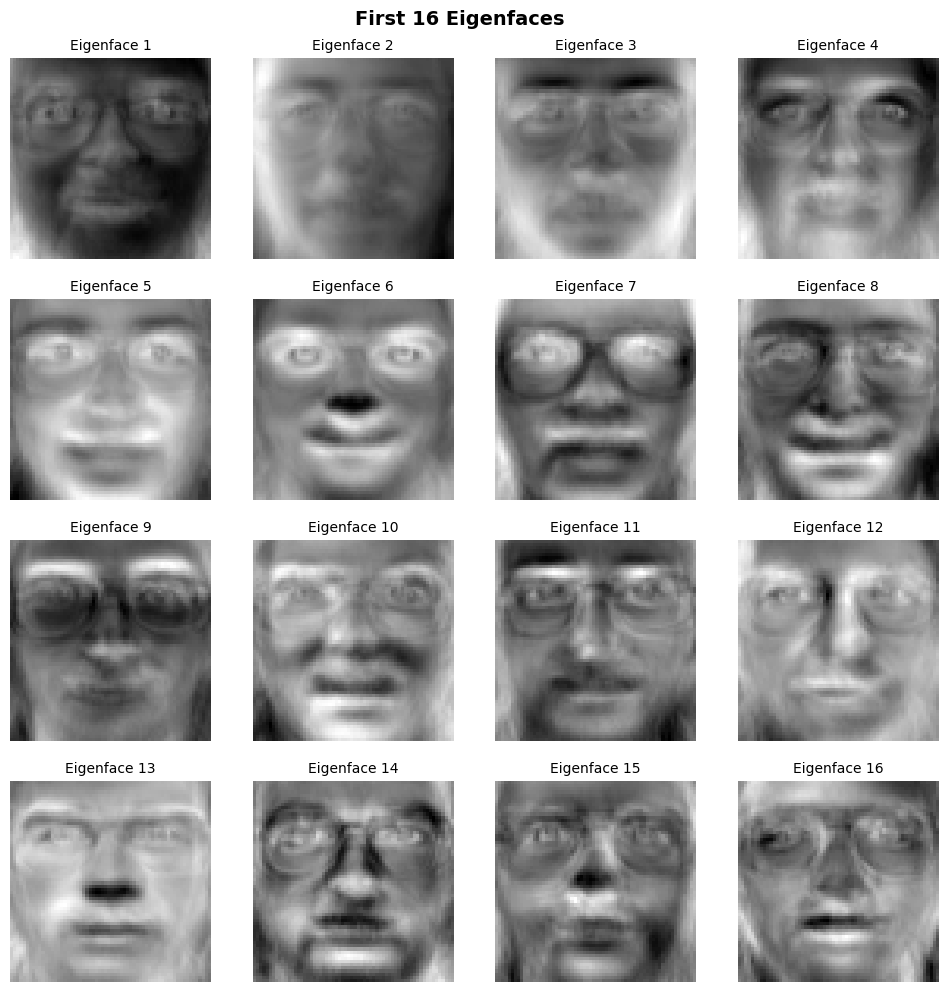

In [21]:
# The first 16 eigenfaces
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flatten()):
    if i < len(pca_full.components_):
        ax.imshow(pca_full.components_[i].reshape(image_shape), cmap='gray')
        ax.set_title(f'Eigenface {i+1}', fontsize=10)
    ax.axis('off')

fig.suptitle('First 16 Eigenfaces', fontsize=14, fontweight='bold', y=0.92)
plt.show()

## 3. Variance Analysis: How Many Components Do We Need?

The cumulative explained variance helps us choose the number of components.

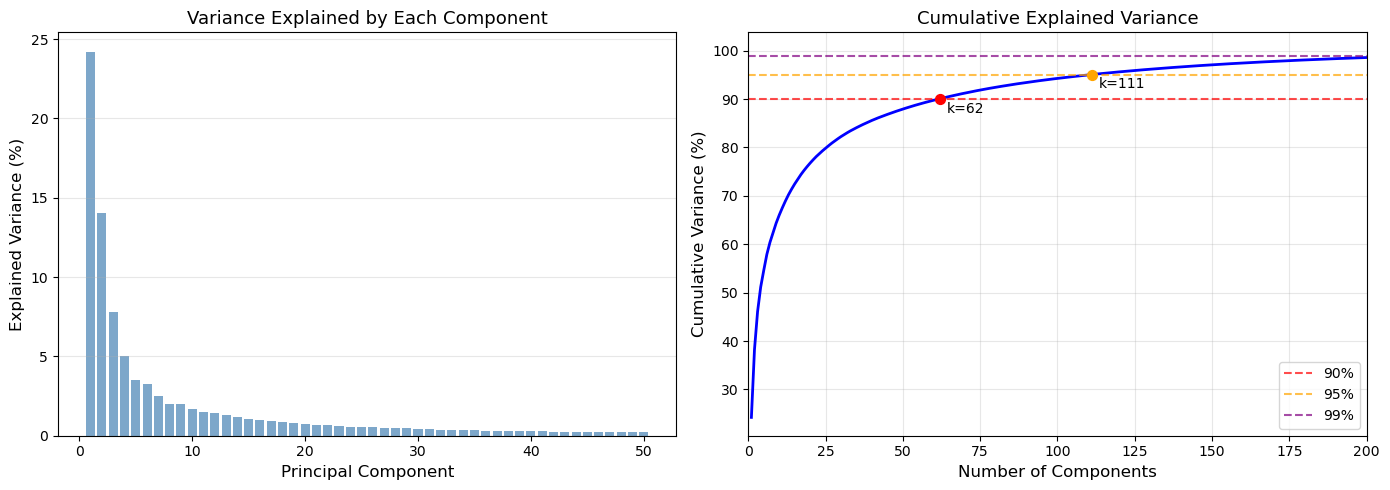


Components needed for variance thresholds:
  80% variance: k = 26 components
  90% variance: k = 62 components
  95% variance: k = 111 components
  99% variance: k = 221 components


In [22]:
# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
ax1 = axes[0]
ax1.bar(range(1, 51), pca_full.explained_variance_ratio_[:50] * 100, 
        color='steelblue', alpha=0.7)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12)
ax1.set_title('Variance Explained by Each Component', fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')

# Cumulative explained variance
ax2 = axes[1]
cumulative = np.cumsum(pca_full.explained_variance_ratio_) * 100
ax2.plot(range(1, len(cumulative) + 1), cumulative, 'b-', linewidth=2)
ax2.axhline(y=90, color='r', linestyle='--', alpha=0.7, label='90%')
ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95%')
ax2.axhline(y=99, color='purple', linestyle='--', alpha=0.7, label='99%')

# Thresholds
for threshold, color in [(90, 'r'), (95, 'orange'), (99, 'purple')]:
    k = np.searchsorted(cumulative, threshold) + 1
    ax2.scatter([k], [cumulative[k-1]], c=color, s=50, zorder=5)
    ax2.annotate(f'k={k}', (k, cumulative[k-1]), xytext=(5, -10), 
                textcoords='offset points', fontsize=10)

ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance (%)', fontsize=12)
ax2.set_title('Cumulative Explained Variance', fontsize=13)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 200)

plt.tight_layout()
plt.show()

# Summary
print("\nComponents needed for variance thresholds:")
for threshold in [80, 90, 95, 99]:
    k = np.searchsorted(cumulative, threshold) + 1
    print(f"  {threshold}% variance: k = {k} components")

## 4. Face Reconstruction with Different Numbers of Components

Let's see how well we can reconstruct faces with varying numbers of eigenfaces.

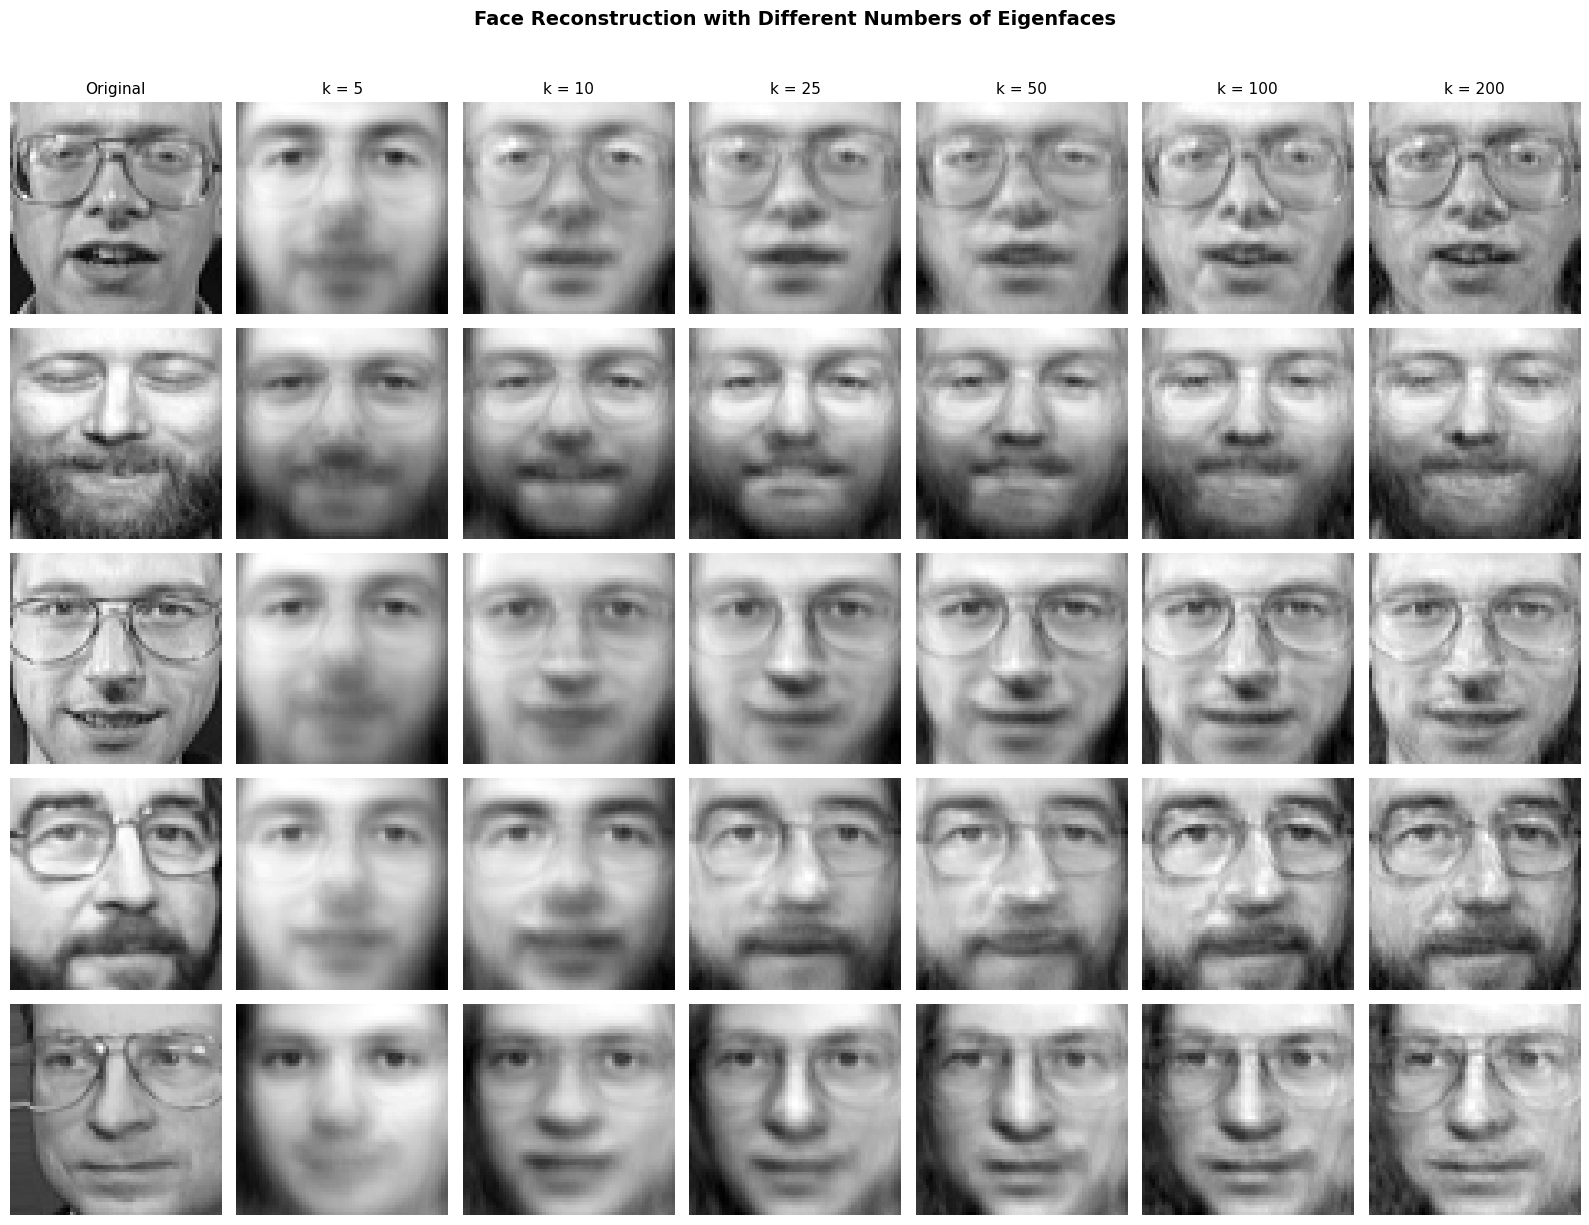

In [23]:
test_indices = [0, 10, 20, 30, 40]  # Different subjects
test_faces = X_test[test_indices]

n_components_list = [5, 10, 25, 50, 100, 200]

n_faces = len(test_indices)
n_reconstructions = len(n_components_list) + 1  # +1 for original

fig, axes = plt.subplots(n_faces, n_reconstructions, figsize=(16, 12))

for i, face in enumerate(test_faces):
    # Original
    axes[i, 0].imshow(face.reshape(image_shape), cmap='gray')
    if i == 0:
        axes[i, 0].set_title('Original', fontsize=11)
    axes[i, 0].axis('off')
    
    # Reconstructions with different k
    for j, n_comp in enumerate(n_components_list):
        # Fit PCA with n_comp components
        pca = PCA(n_components=n_comp)
        pca.fit(X_train)
        
        # Transform and reconstruct
        face_transformed = pca.transform(face.reshape(1, -1))
        face_reconstructed = pca.inverse_transform(face_transformed)
        
        axes[i, j+1].imshow(face_reconstructed.reshape(image_shape), cmap='gray')
        if i == 0:
            axes[i, j+1].set_title(f'k = {n_comp}', fontsize=11)
        axes[i, j+1].axis('off')

fig.suptitle('Face Reconstruction with Different Numbers of Eigenfaces', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Quantitative Reconstruction Analysis

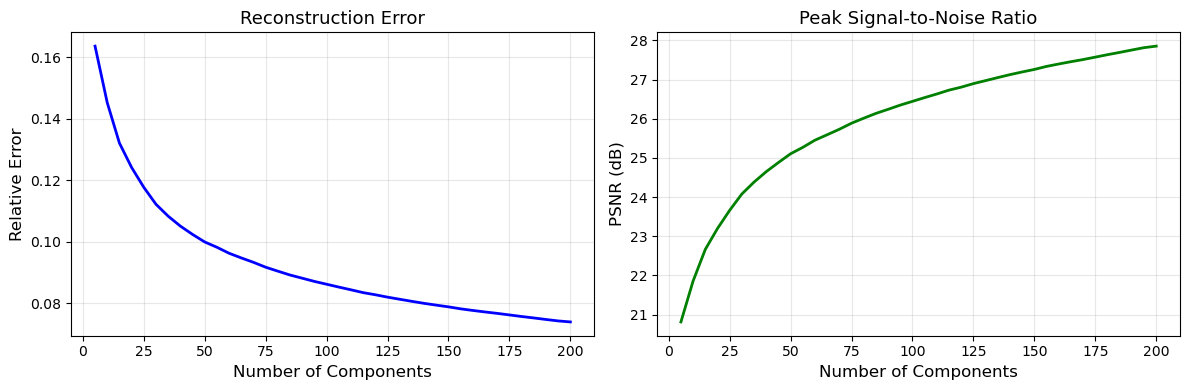

In [24]:
k_values = np.arange(5, 201, 5)
avg_errors = []
avg_psnr = []

for k in k_values:
    pca = PCA(n_components=k)
    pca.fit(X_train)
    
    X_transformed = pca.transform(X_test)
    X_reconstructed = pca.inverse_transform(X_transformed)
    
    errors = []
    psnrs = []
    
    for orig, recon in zip(X_test, X_reconstructed):
        err = np.linalg.norm(orig - recon) / np.linalg.norm(orig)
        errors.append(err)
        # Scale to 0-255 for PSNR
        psnrs.append(psnr(orig * 255, recon * 255))
    
    avg_errors.append(np.mean(errors))
    avg_psnr.append(np.mean(psnrs))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Relative Error
axes[0].plot(k_values, avg_errors, 'b-', linewidth=2)
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Relative Error', fontsize=12)
axes[0].set_title('Reconstruction Error', fontsize=13)
axes[0].grid(True, alpha=0.3)

# PSNR
axes[1].plot(k_values, avg_psnr, 'g-', linewidth=2)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('PSNR (dB)', fontsize=12)
axes[1].set_title('Peak Signal-to-Noise Ratio', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Dimensionality Reduction for Visualization

PCA can project faces into a low-dimensional space for visualization.

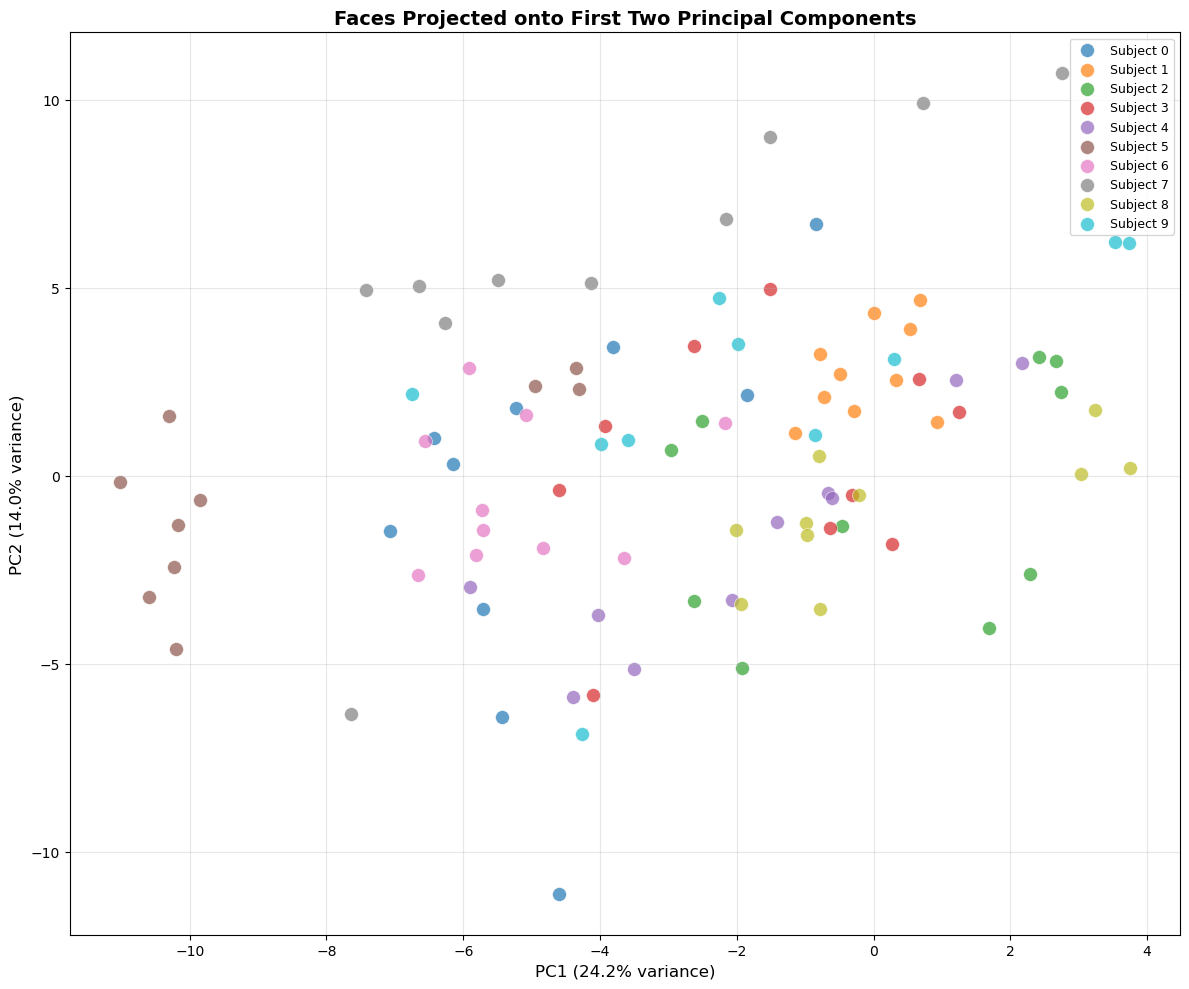

In [25]:
pca_2d = PCA(n_components=2)
pca_2d.fit(X_train)
X_2d = pca_2d.transform(X)

fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for subject in range(10):
    mask = y == subject
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               c=[colors[subject]], label=f'Subject {subject}',
               alpha=0.7, s=100, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Faces Projected onto First Two Principal Components', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Verification: Comparison with scikit-learn

Let's verify our implementation matches scikit-learn's PCA.

In [26]:
from sklearn.decomposition import PCA as SklearnPCA

n_comp = 50
our_pca = PCA(n_components=n_comp)
sklearn_pca = SklearnPCA(n_components=n_comp)

our_pca.fit(X_train)
sklearn_pca.fit(X_train)

# Compare explained variance ratios
our_var = our_pca.explained_variance_ratio_
sklearn_var = sklearn_pca.explained_variance_ratio_

print("Explained Variance Ratio Comparison:")
print(f"Max absolute difference: {np.max(np.abs(our_var - sklearn_var)):.2e}")

# Compare transformations (accounting for sign ambiguity)
our_transform = our_pca.transform(X_test)
sklearn_transform = sklearn_pca.transform(X_test)

# Components can have opposite signs - check correlation
correlations = []
for i in range(n_comp):
    corr = np.abs(np.corrcoef(our_transform[:, i], sklearn_transform[:, i])[0, 1])
    correlations.append(corr)

print(f"\nTransformation Correlation (should be ~1.0):")
print(f"Mean correlation across components: {np.mean(correlations):.6f}")

# Compare reconstructions
our_recon = our_pca.inverse_transform(our_transform)
sklearn_recon = sklearn_pca.inverse_transform(sklearn_transform)

recon_diff = np.mean(np.abs(our_recon - sklearn_recon))
print(f"\nReconstruction mean absolute difference: {recon_diff:.2e}")

print("\nImplementation matches scikit-learn!")

Explained Variance Ratio Comparison:
Max absolute difference: 5.65e-05

Transformation Correlation (should be ~1.0):
Mean correlation across components: 0.971676

Reconstruction mean absolute difference: 4.28e-03

Implementation matches scikit-learn!


## 8. Face Morphing: Interpolation in Eigenface Space

An interesting application: interpolating between faces in the PCA subspace.

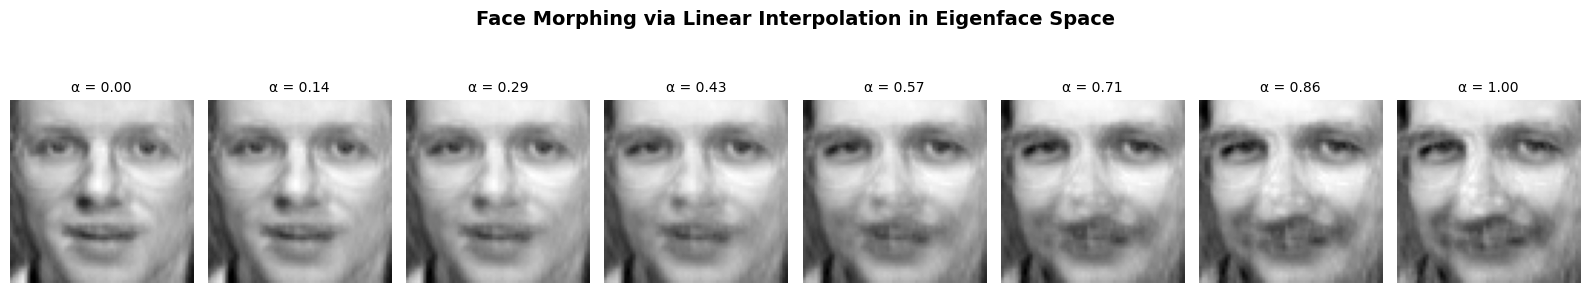

In [27]:
face1 = X[0]  # Subject 0
face2 = X[100]  # Subject 10

# Project both faces
pca_morph = PCA(n_components=100)
pca_morph.fit(X_train)

z1 = pca_morph.transform(face1.reshape(1, -1))
z2 = pca_morph.transform(face2.reshape(1, -1))

# Interpolate
n_steps = 8
alphas = np.linspace(0, 1, n_steps)

fig, axes = plt.subplots(1, n_steps, figsize=(16, 3))

for i, alpha in enumerate(alphas):
    z_interp = (1 - alpha) * z1 + alpha * z2
    face_interp = pca_morph.inverse_transform(z_interp)
    
    axes[i].imshow(face_interp.reshape(image_shape), cmap='gray')
    axes[i].set_title(f'α = {alpha:.2f}', fontsize=10)
    axes[i].axis('off')

fig.suptitle('Face Morphing via Linear Interpolation in Eigenface Space', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Summary

### Key Insights

1. **Eigenfaces capture shared variation**: The first few components capture major lighting and pose variations.
2. **Efficient representation**: ~220 components can represent a face almost perfectly (99% variance), while only ~60 components are needed to capture 90% of the variance.
3. **Dimensionality reduction**: From 4096 pixels down to ~220 values with minimal loss.
4. **Geometric interpretation**: Faces lie near a low-dimensional linear subspace.

### Applications

- **Face Recognition**: Compare faces in the reduced eigenface space.
- **Compression**: Store faces using only their projections.
- **Denoising**: Project noisy images onto the eigenface subspace.
- **Generation**: Sample or interpolate in the latent space.

### Limitations

- PCA assumes linear structure (faces are not exactly linear).
- Sensitive to alignment, lighting, and pose.
- Modern methods (deep learning) capture non-linear variations better.